In [2]:
import os
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import optuna

# =========================================================
# GLOBAL PRL SINGLE-COLUMN PUBLICATION STYLING
# =========================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'], 
    'font.size': 9, 
    'axes.labelsize': 9, 
    'axes.titlesize': 9,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 300, 
    'savefig.dpi': 300, 
    'savefig.bbox': 'tight'
})

PAPER_COLORS = {
    'Neural Net': '#404040', 'Deep Neural Network': '#404040', 'CNN (Native)': '#404040',
    'XGBoost': '#B2182B', 'XGBoost (Raw)': '#B2182B',
    'LightGBM': '#D6604D', 'LightGBM (Raw)': '#D6604D',
    'CatBoost': '#F4A582', 'CatBoost (Raw)': '#F4A582',
    'XGBoost (CNN Feat)': '#2166AC', 'LightGBM (CNN Feat)': '#4393C3', 'CatBoost (CNN Feat)': '#92C5DE',
    'RandomForest': '#2166AC', 'GradientBoost': '#4393C3'
}

print("✅ Global setup complete. Strict Single-Column Styling loaded.")

✅ Global setup complete. Strict Single-Column Styling loaded.


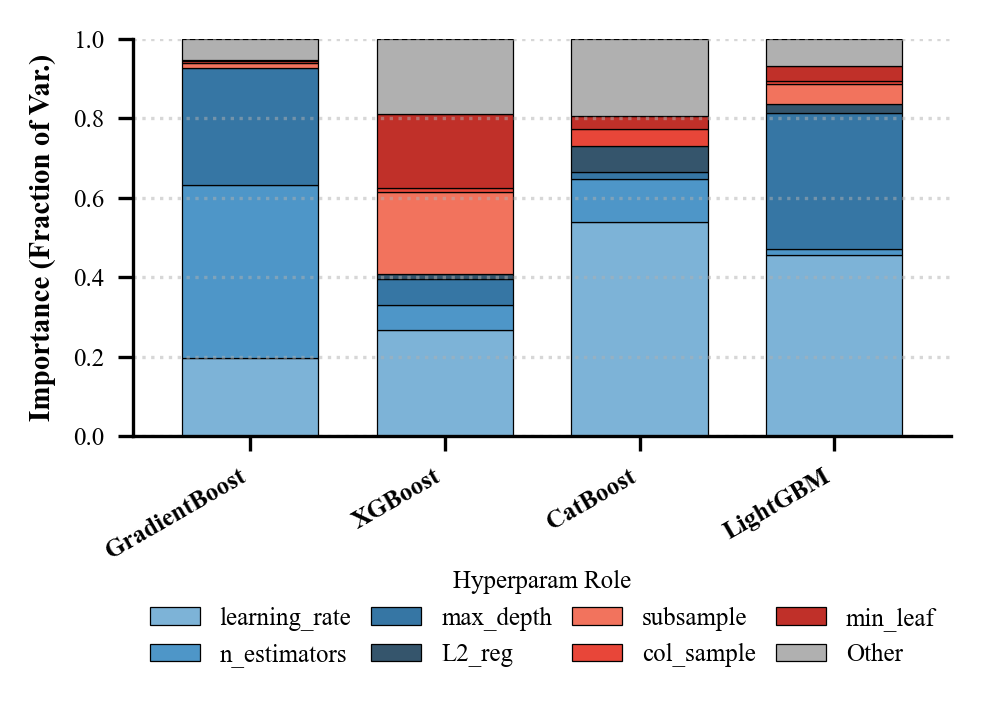

In [6]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna.importance
import os

# 1. Load the saved Optuna studies from the .pkl files
study_gbm = joblib.load('study_gbm.pkl')
study_xgb = joblib.load('study_xgb.pkl')
study_cb = joblib.load('study_cb.pkl')
study_lgb = joblib.load('study_lgb.pkl')

studies = [study_gbm, study_xgb, study_cb, study_lgb]
model_names = ['GradientBoost', 'XGBoost', 'CatBoost', 'LightGBM']

# 2. Map raw parameter names to common roles
param_role = {
    'learning_rate': 'learning_rate',
    'n_estimators': 'n_estimators',
    'max_depth': 'max_depth',
    'subsample': 'subsample',
    'max_features': 'col_sample',
    'min_samples_leaf': 'min_leaf',
    'gamma': None, 'reg_lambda': 'L2_reg',
    'colsample_bytree': 'col_sample',
    'min_child_weight': 'min_leaf',
    'iterations': 'n_estimators',
    'depth': 'max_depth',
    'l2_leaf_reg': 'L2_reg',
    'random_strength': None,
    'bagging_temperature': None,
    'scale_pos_weight': None,
    'colsample_bylevel': 'col_sample',
    'min_data_in_leaf': 'min_leaf',
    'min_child_samples': 'min_leaf',
}

roles = ['learning_rate', 'n_estimators', 'max_depth', 'L2_reg',
         'subsample', 'col_sample', 'min_leaf']

# 3. Extract importances and calculate the "Other" remainder to reach 1.0
data = {model: {role: 0.0 for role in roles} for model in model_names}

for study, model in zip(studies, model_names):
    importances = optuna.importance.get_param_importances(study)
    for param, imp in importances.items():
        role = param_role.get(param)
        if role in data[model]:
            data[model][role] += imp
            
    # Calculate the missing area to reach exactly 1.0
    mapped_sum = sum(data[model].values())
    data[model]['Other'] = max(0.0, 1.0 - mapped_sum)

df_imp = pd.DataFrame(data).T   # models as rows, parameters as columns

# 4. Create Plot with PRL Formatting
fig, ax = plt.subplots(figsize=(3.375, 2.8))

# Define a professional Blue-Red palette
blue_shades = sns.color_palette("Blues_d", n_colors=len(roles)//2 + 1)
red_shades = sns.color_palette("Reds_d", n_colors=len(roles)//2 + 1)

# Combine, slice, and append standard Grey for "Other"
custom_colors = list((blue_shades + red_shades)[:len(roles)])
custom_colors.append('#B0B0B0') # Professional neutral grey

# Apply custom formatting
df_imp.plot(kind='bar', stacked=True, ax=ax, width=0.7, color=custom_colors, edgecolor='black', linewidth=0.3)

# Formatting for PRL single-column
ax.set_ylabel('Importance (Fraction of Var.)', weight='bold', fontsize=7)
ax.set_xticklabels(model_names, weight='bold', rotation=30, ha='right', fontsize=6)

# Force Y-axis to exactly 1.0 with explicitly defined ticks
ax.set_ylim(0, 1.0)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.grid(axis='y', linestyle=':', alpha=0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=6)
ax.set_xlabel('') 

# Compact Legend (added an extra column to accommodate 'Other')
ax.legend(
    title='Hyperparam Role', 
    bbox_to_anchor=(0.5, -0.28), 
    loc='upper center', 
    ncol=4,                      
    frameon=False, 
    fontsize=6, 
    title_fontsize=6,
    columnspacing=0.8
)

# Ensure the output directory exists
os.makedirs('plots', exist_ok=True)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('plots/Hyperparameter_Importance.pdf', bbox_inches='tight')
plt.show()

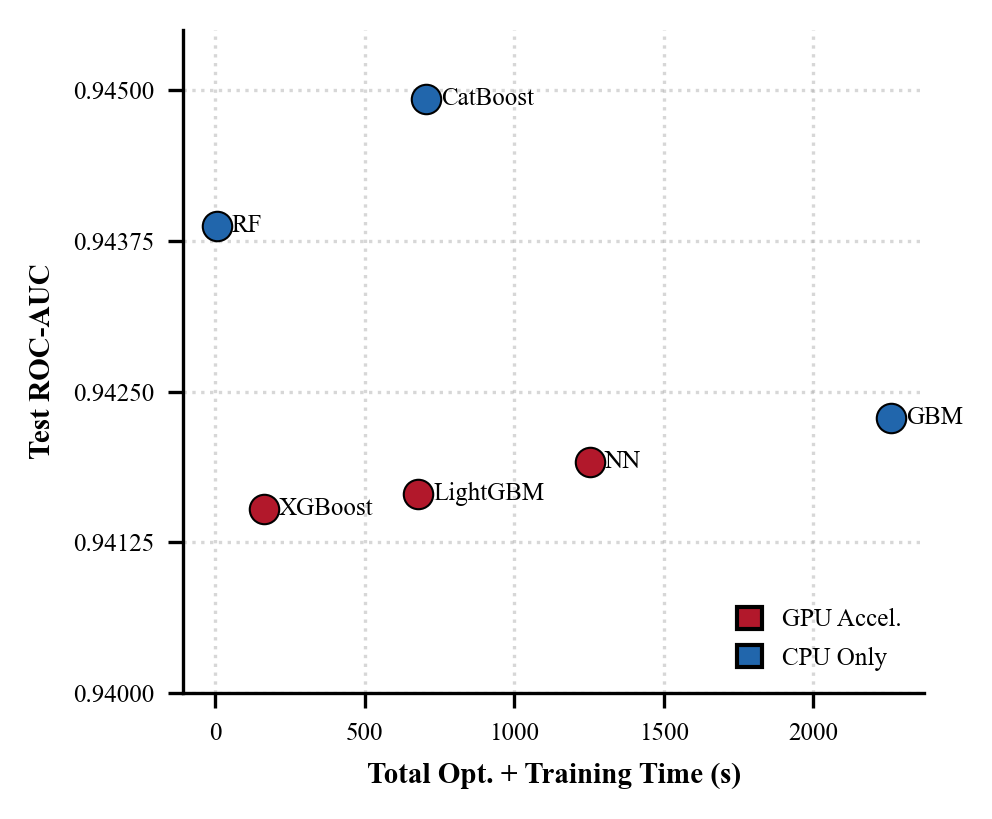

In [15]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import os

# 1. Load the data from the .pkl files
clean_metrics = joblib.load('clean_metrics.pkl')
elapsed_times = joblib.load('elapsed_times.pkl')

# Extract AUC metrics (Y-axis)
roc_auc_clean_rf  = clean_metrics['rf']['auc']
roc_auc_clean_gbm = clean_metrics['gbm']['auc']
roc_auc_clean_xgb = clean_metrics['xgb']['auc']
roc_auc_clean_cb  = clean_metrics['cb']['auc']
roc_auc_clean_lgb = clean_metrics['lgb']['auc']
roc_auc_clean_nn  = clean_metrics['nn']['auc']

# Extract Elapsed Times (X-axis)
elapsed_rf      = elapsed_times.get('rf_train', 0)
elapsed_gbm     = elapsed_times.get('gbm_optuna', 0)
elapsed_xgb     = elapsed_times.get('xgb_optuna', 0)
elapsed_cb      = elapsed_times.get('cb_optuna', 0)
elapsed_lgb     = elapsed_times.get('lgb_optuna', 0)
elapsed_nn_tune = elapsed_times.get('nn_optuna', 0)
elapsed_nn      = elapsed_times.get('nn_final', 0)

# Calculate final plot arrays
times = [elapsed_rf / 50, elapsed_gbm, elapsed_xgb, elapsed_cb,
         elapsed_lgb, elapsed_nn_tune + elapsed_nn]
aucs = [roc_auc_clean_rf, roc_auc_clean_gbm, roc_auc_clean_xgb,
        roc_auc_clean_cb, roc_auc_clean_lgb, roc_auc_clean_nn]
labels = ['RF', 'GBM', 'XGBoost', 'CatBoost', 'LightGBM', 'NN']

# GPU‑exclusive tasks: XGBoost, LightGBM, NN (zero‑based indices)
gpu_idx = [2, 4, 5]

# 2. Create the Plot with PRL Formatting
fig, ax = plt.subplots(figsize=(3.375, 2.8)) # Standard PRL single-column size

# Plot each point
for i, (x, y, lab) in enumerate(zip(times, aucs, labels)):
    # Use professional dark red for GPU, navy blue for CPU
    col = '#b2182b' if i in gpu_idx else '#2166ac' 
    ax.scatter(x, y, s=50, color=col, edgecolors='black', linewidth=0.5, zorder=5)
    
    # Add text labels next to the points
    # Adjusted offset slightly so text doesn't overlap the marker
    ax.text(x + 50, y, lab, fontsize=6, verticalalignment='center')

# Formatting for PRL
ax.set_xlabel('Total Opt. + Training Time (s)', weight='bold', fontsize=7)
ax.set_ylabel('Test ROC-AUC', weight='bold', fontsize=7)

# Set Y-limits exactly as requested
ax.set_ylim([0.94, 0.9455])
ax.set_yticks(np.linspace(0.94, 0.945, 5))

# Grid and spines
ax.grid(linestyle=':', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=6)

# Compact Legend
legend_elements = [
    Patch(facecolor='#b2182b', edgecolor='black', label='GPU Accel.'),
    Patch(facecolor='#2166ac', edgecolor='black', label='CPU Only')
]

ax.legend(
    handles=legend_elements,
    loc='lower right', 
    frameon=False, 
    fontsize=6, 
    handlelength=1.0,
    handleheight=1.0
)

# Ensure output directory exists
os.makedirs('plots', exist_ok=True)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('plots/magic_performances.pdf', bbox_inches='tight')
plt.show()

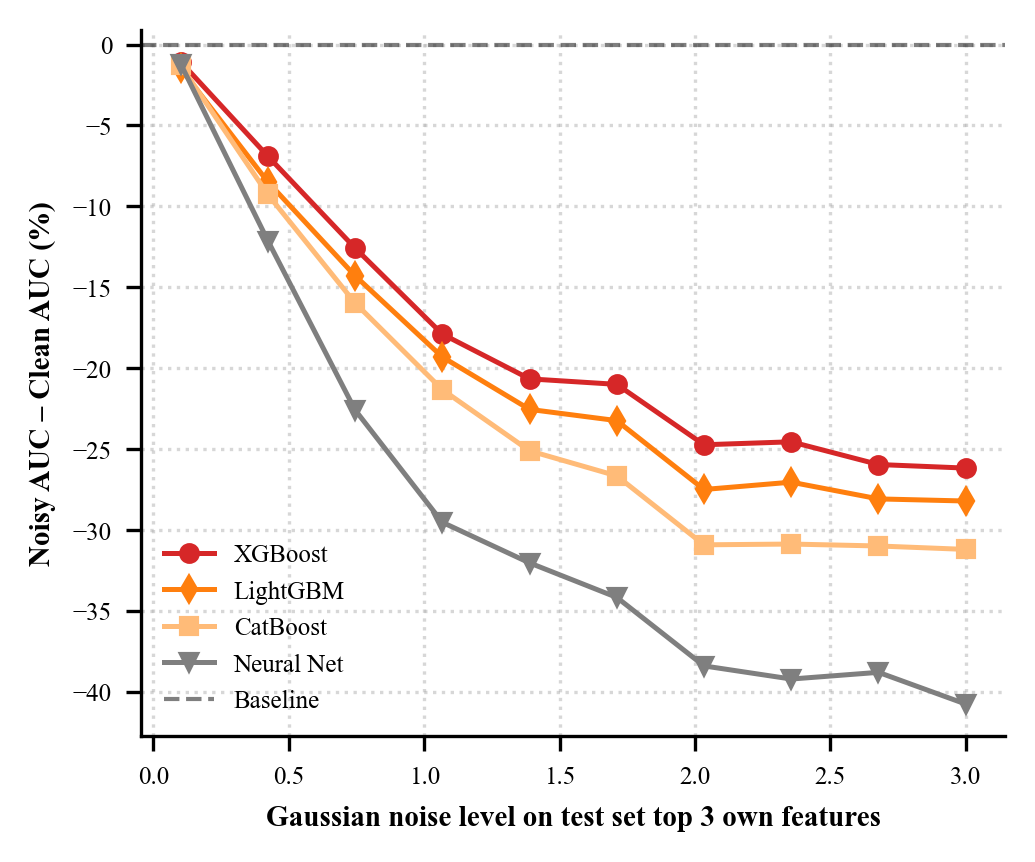

In [12]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt

# Ensure output directory exists
os.makedirs('plots/Phase2_Degradation', exist_ok=True)

# ==========================================
# 1. Load Data
# ==========================================
# Try loading from the 'Data' folder first, fallback to current directory
try:
    results = joblib.load('Data/targeted_noise_results.pkl')
except FileNotFoundError:
    results = joblib.load('targeted_noise_results.pkl')

noise_levels = results['noise_levels_target']

# Multiply by -100 to show the performance drop as a positive percentage
xgb_drop = -100 * np.asarray(results['auc_drop_xgb_target'])
cb_drop  = -100 * np.asarray(results['auc_drop_cb_target'])
lgb_drop = -100 * np.asarray(results['auc_drop_lgb_target'])
nn_drop  = -100 * np.asarray(results['auc_drop_nn_target'])

# ==========================================
# 2. PRL Formatted Plot
# ==========================================
fig, ax = plt.subplots(figsize=(3.375, 2.8)) # PRL single-column width

# Plot lines with professional colors and markers
# XGBoost: Red, LightGBM: Orange, CatBoost: Light Orange, NN: Gray
ax.plot(noise_levels, xgb_drop, marker='o', markersize=4, linestyle='-', linewidth=1.2, 
        color='#d62728', label='XGBoost')
ax.plot(noise_levels, lgb_drop, marker='d', markersize=4, linestyle='-', linewidth=1.2, 
        color='#ff7f0e', label='LightGBM')
ax.plot(noise_levels, cb_drop, marker='s', markersize=4, linestyle='-', linewidth=1.2, 
        color='#ffbb78', label='CatBoost')
ax.plot(noise_levels, nn_drop, marker='v', markersize=4, linestyle='-', linewidth=1.2, 
        color='#7f7f7f', label='Neural Net')

# Baseline (No degradation)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.0, alpha=0.5, label='Baseline')

# Formatting (No Title, LaTeX-friendly labels)
ax.set_xlabel('Gaussian noise level on test set top 3 own features', weight='bold', fontsize=7)
ax.set_ylabel('Noisy AUC – Clean AUC (%)', weight='bold', fontsize=7)

# PRL Grid and Spines
ax.grid(linestyle=':', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=6)

# Borderless Legend
ax.legend(loc='best', frameon=False, fontsize=6)

# Save and Show
plt.tight_layout(pad=0.5)
plt.savefig('Targeted_Noise_Robustness.pdf', bbox_inches='tight')
plt.show()

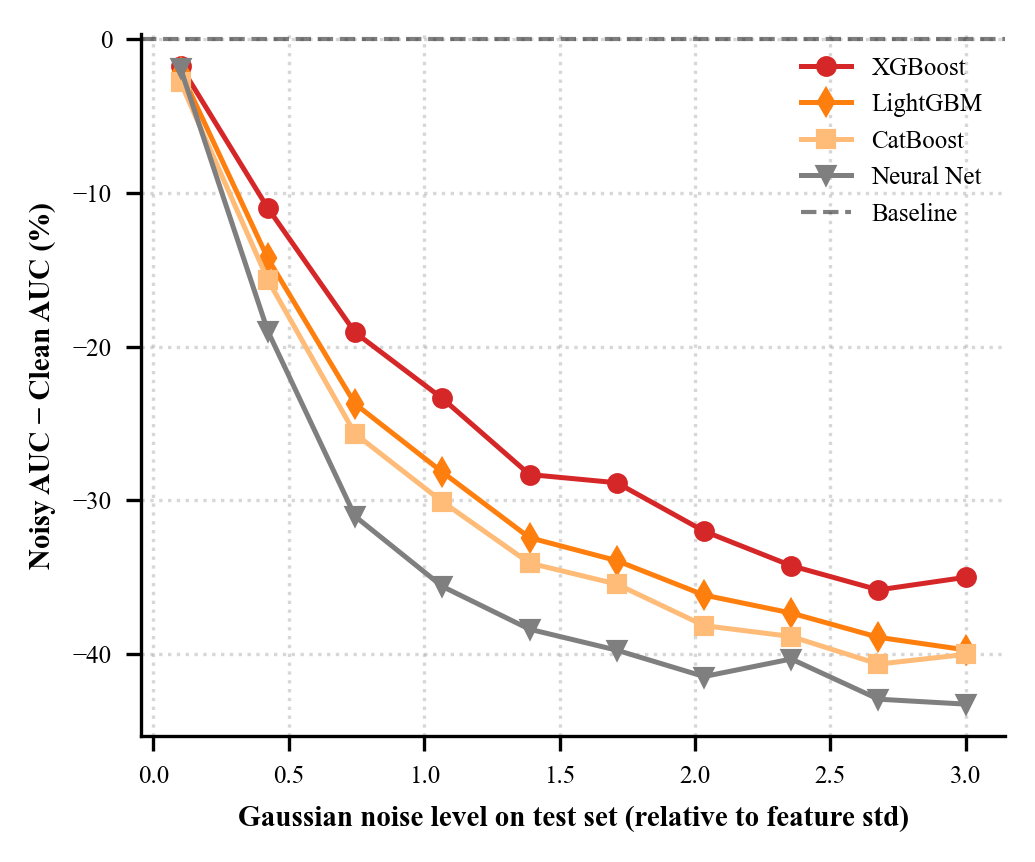

In [9]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt

# Ensure output directory exists
os.makedirs('plots/Phase2_Degradation', exist_ok=True)

# ==========================================
# 1. Load Data
# ==========================================
# Try loading from the 'Data' folder first, fallback to current directory
try:
    results = joblib.load('Data/noisy_test_results.pkl')
except FileNotFoundError:
    results = joblib.load('noisy_test_results.pkl')

noise_levels = results['noise_levels_noisy_test']

# Multiply by -100 to show the performance drop as a positive percentage
xgb_drop = -100 * np.asarray(results['auc_drop_xgb_ntest'])
cb_drop  = -100 * np.asarray(results['auc_drop_cb_ntest'])
lgb_drop = -100 * np.asarray(results['auc_drop_lgb_ntest'])
nn_drop  = -100 * np.asarray(results['auc_drop_nn_ntest'])

# ==========================================
# 2. PRL Formatted Plot
# ==========================================
fig, ax = plt.subplots(figsize=(3.375, 2.8)) # PRL single-column width

# Plot lines with professional colors and markers
# XGBoost: Red, LightGBM: Orange, CatBoost: Light Orange, NN: Gray
ax.plot(noise_levels, xgb_drop, marker='o', markersize=4, linestyle='-', linewidth=1.2, 
        color='#d62728', label='XGBoost')
ax.plot(noise_levels, lgb_drop, marker='d', markersize=4, linestyle='-', linewidth=1.2, 
        color='#ff7f0e', label='LightGBM')
ax.plot(noise_levels, cb_drop, marker='s', markersize=4, linestyle='-', linewidth=1.2, 
        color='#ffbb78', label='CatBoost')
ax.plot(noise_levels, nn_drop, marker='v', markersize=4, linestyle='-', linewidth=1.2, 
        color='#7f7f7f', label='Neural Net')

# Baseline (No degradation)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.0, alpha=0.5, label='Baseline')

# Formatting (No Title, LaTeX-friendly labels)
ax.set_xlabel('Gaussian noise level on test set (relative to feature std)', weight='bold', fontsize=7)
ax.set_ylabel('Noisy AUC − Clean AUC (%)', weight='bold', fontsize=7)

# PRL Grid and Spines
ax.grid(linestyle=':', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=6)

# Borderless Legend
ax.legend(loc='best', frameon=False, fontsize=6)

# Save and Show
plt.tight_layout(pad=0.5)
plt.savefig('Global_Noise_Robustness.pdf', bbox_inches='tight')
plt.show()